### 1. Import Libraries

In [48]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 2. Configuration

In [49]:
DATA_PATH = r"E:\Zidio Development\Project_FORESIGHT\data\processed/processed_data.csv"
FIG_SIZE = (12,6)
RANDOM_STATE = 42

### 3. Load Dataset

In [50]:
df = pd.read_csv(DATA_PATH)
print(df.head())

         Date  SKU_ID  Product_Name   Category  Units_Sold  Unit_Price  \
0  01-01-2025     101  Office Chair  Furniture          25         550   
1  01-01-2025     102   Study Table  Furniture          18         700   
2  01-01-2025     103     Desk Lamp   Lighting          32         450   
3  01-01-2025     104     Bookshelf  Furniture          20         800   
4  02-01-2025     101  Office Chair  Furniture          30         550   

   List_Price  On_Hand_Units  On_Order_Units  Is_Weekend  Total_Sales  
0         600            120              50           0        13750  
1         750             80              20           0        12600  
2         500             95              30           0        14400  
3         900            110              40           0        16000  
4         600            118              50           0        16500  


### 4. Dataset Overview

In [51]:
# Shape
print(df.shape)

# Information
df.info()

# Columns
print(df.columns)

# Data Types
print(df.dtypes)

(80, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            80 non-null     object
 1   SKU_ID          80 non-null     int64 
 2   Product_Name    80 non-null     object
 3   Category        80 non-null     object
 4   Units_Sold      80 non-null     int64 
 5   Unit_Price      80 non-null     int64 
 6   List_Price      80 non-null     int64 
 7   On_Hand_Units   80 non-null     int64 
 8   On_Order_Units  80 non-null     int64 
 9   Is_Weekend      80 non-null     int64 
 10  Total_Sales     80 non-null     int64 
dtypes: int64(8), object(3)
memory usage: 7.0+ KB
Index(['Date', 'SKU_ID', 'Product_Name', 'Category', 'Units_Sold',
       'Unit_Price', 'List_Price', 'On_Hand_Units', 'On_Order_Units',
       'Is_Weekend', 'Total_Sales'],
      dtype='object')
Date              object
SKU_ID             int64
Product_Name      ob

### 5. Basic Statistics

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SKU_ID,80.0,102.5000,1.125088,101.0,101.75,102.5,103.25,104.0
Units_Sold,80.0,24.9125,5.592024,15.0,20.00,24.0,30.00,35.0
Unit_Price,80.0,625.0000,135.478524,450.0,525.00,625.0,725.00,800.0
List_Price,80.0,687.5000,152.510635,500.0,575.00,675.0,787.50,900.0
On_Hand_Units,80.0,80.7125,19.301862,40.0,67.50,81.0,94.25,120.0
On_Order_Units,80.0,26.0750,10.492644,8.0,18.00,25.0,35.00,50.0
Is_Weekend,80.0,0.3000,0.461149,0.0,0.00,0.0,1.00,1.0
Total_Sales,80.0,14976.2500,2215.008858,10500.0,13300.00,14700.0,16575.00,19250.0


### 6 Missing Value Analysis

In [54]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing = missing.sort_values(by="Missing Percentage", ascending=False)
missing

,Missing Count,Missing Percentage
Date,0,0.0
SKU_ID,0,0.0
Product_Name,0,0.0
Category,0,0.0
Units_Sold,0,0.0
Unit_Price,0,0.0
List_Price,0,0.0
On_Hand_Units,0,0.0
On_Order_Units,0,0.0
Is_Weekend,0,0.0


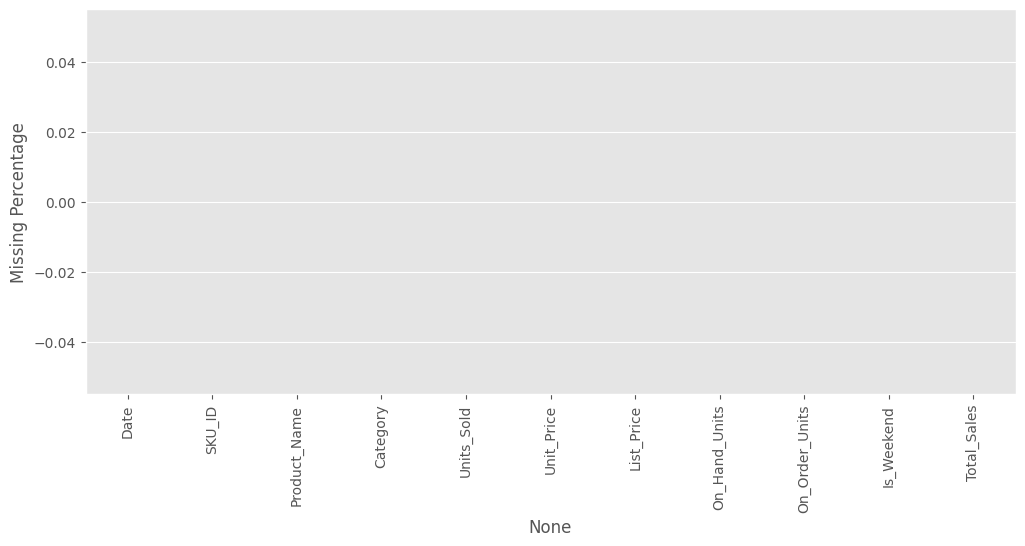

In [55]:
#Missing Value Plot
plt.figure(figsize=(12,5))
sns.barplot(x=missing.index, y=missing["Missing Percentage"])
plt.xticks(rotation=90)
plt.show()

### 7. Duplicate Records

In [56]:
duplicates = df.duplicated().sum()
print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [57]:
df = df.drop_duplicates()

### 8. Numerical Features

In [58]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['SKU_ID', 'Units_Sold', 'Unit_Price', 'List_Price', 'On_Hand_Units',
       'On_Order_Units', 'Is_Weekend', 'Total_Sales'],
      dtype='object')

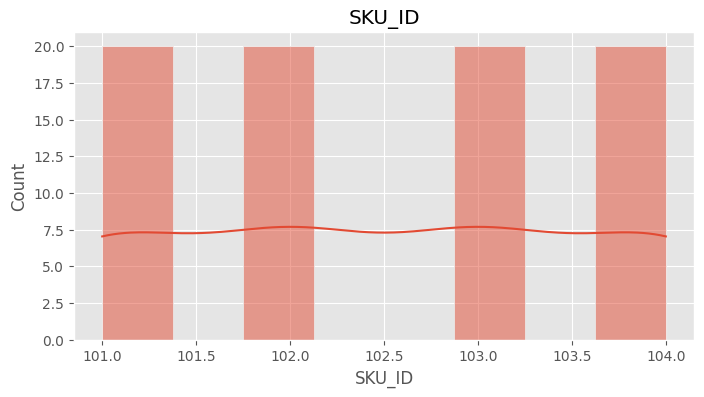

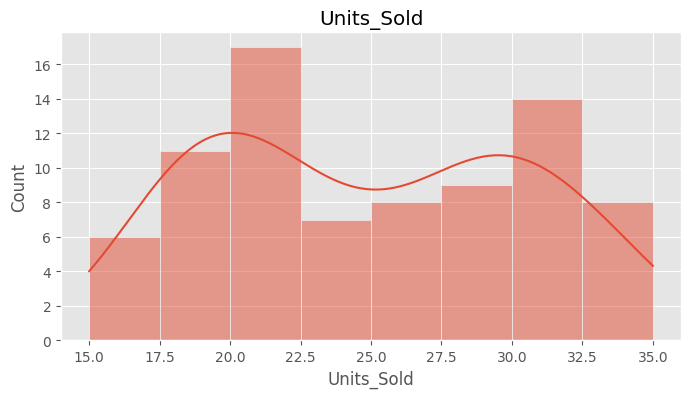

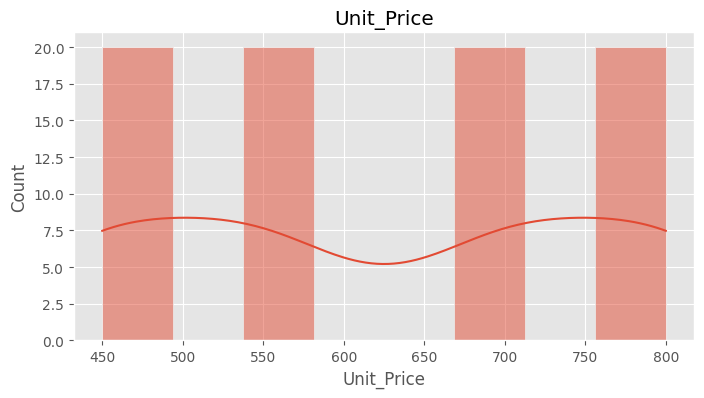

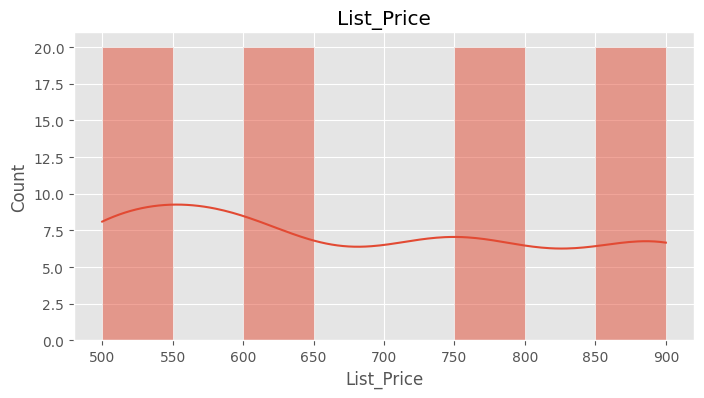

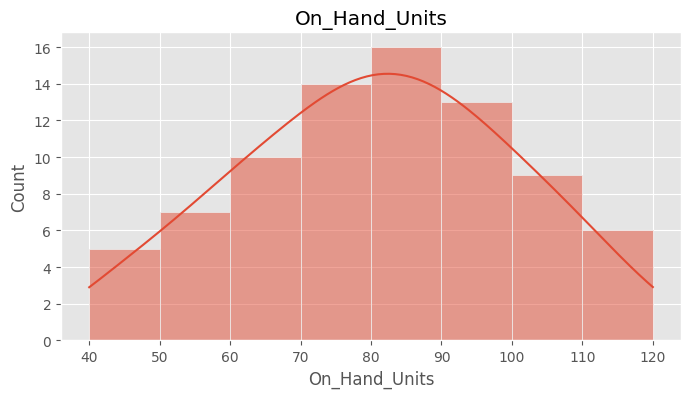

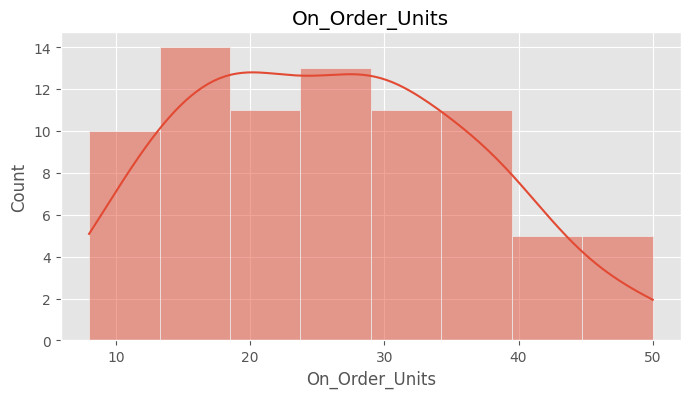

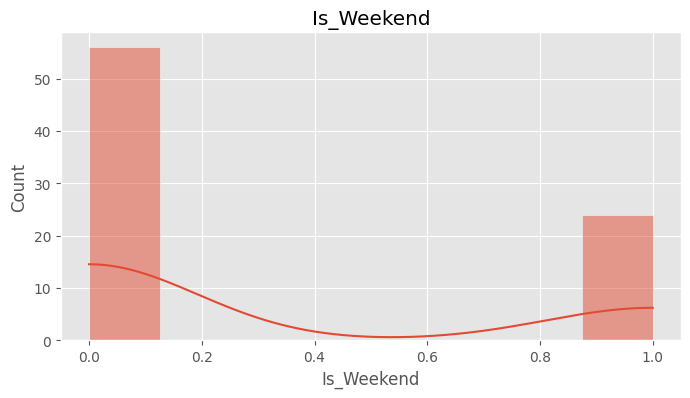

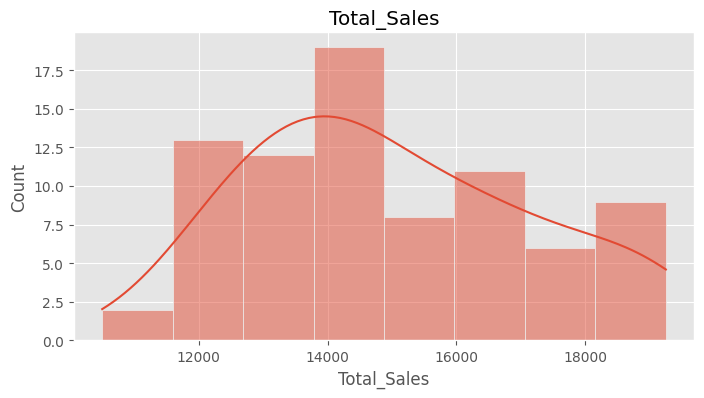

In [59]:
#Distribution
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### 9. Boxplot (Outlier Visualization)

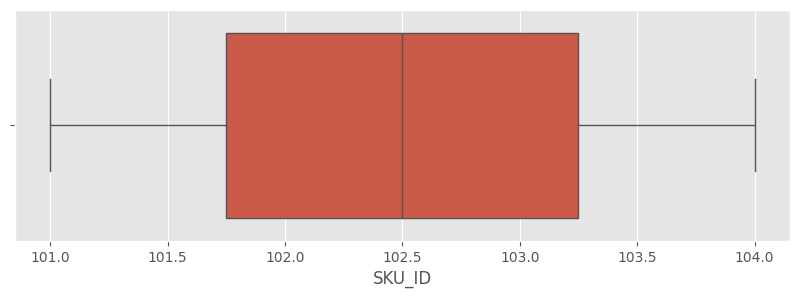

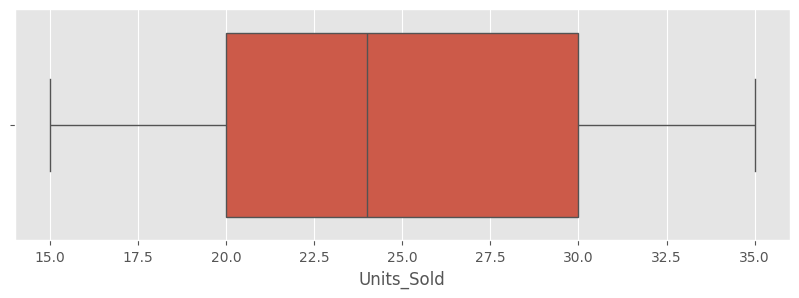

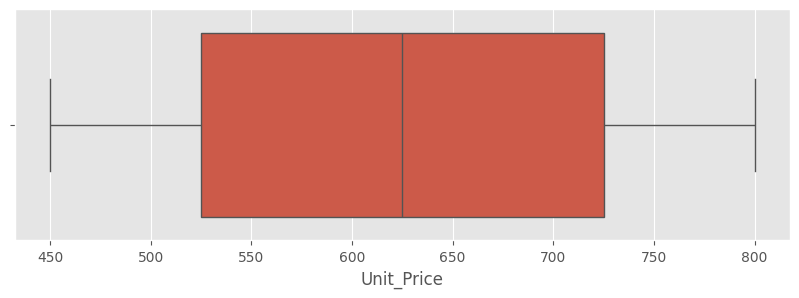

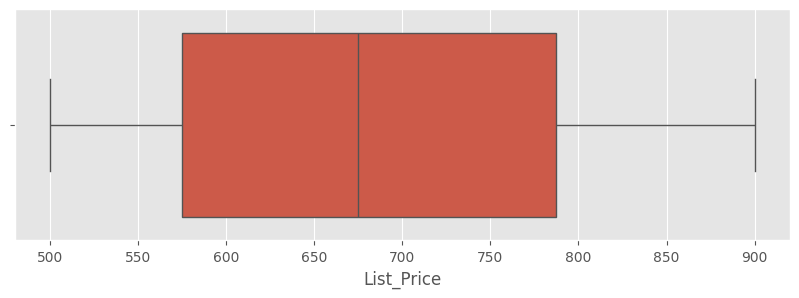

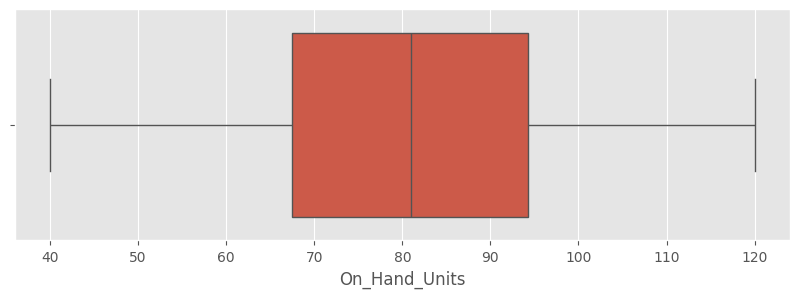

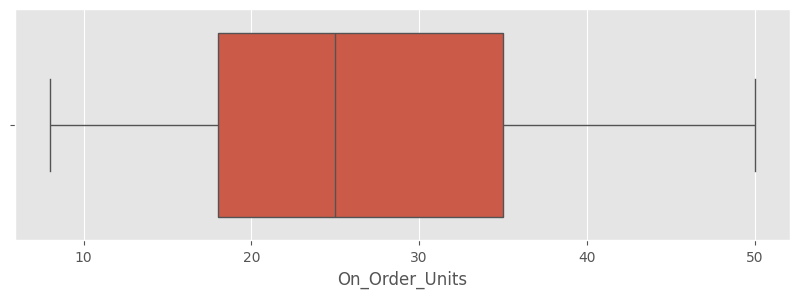

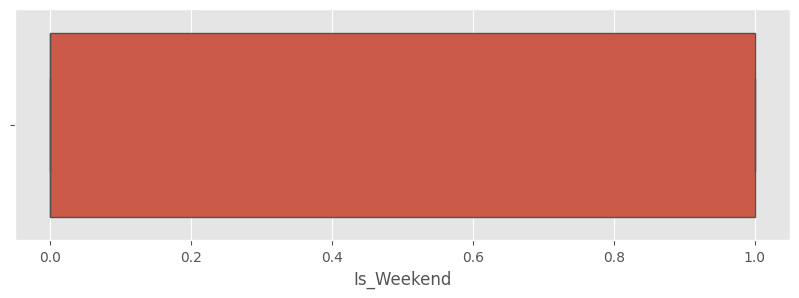

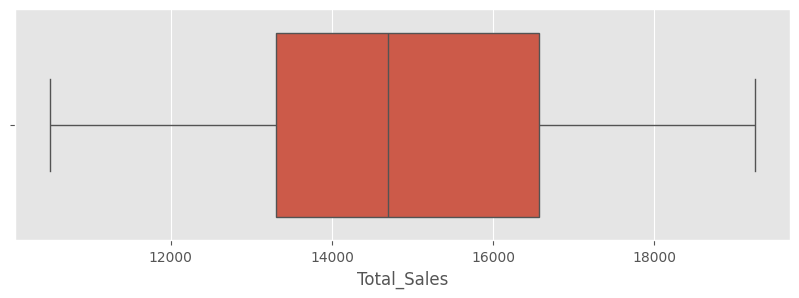

In [60]:
for col in num_cols:
    plt.figure(figsize=(10,3))
    sns.boxplot(x=df[col])
    plt.show()

### 10. Outlier Detection (IQR)

In [61]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col)
    print("Outliers :", len(outliers))

SKU_ID
Outliers : 0
Units_Sold
Outliers : 0
Unit_Price
Outliers : 0
List_Price
Outliers : 0
On_Hand_Units
Outliers : 0
On_Order_Units
Outliers : 0
Is_Weekend
Outliers : 0
Total_Sales
Outliers : 0


### 11. Categorical Features

In [62]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['Date', 'Product_Name', 'Category'], dtype='object')

In [63]:
#Value Counts
for col in cat_cols:
    print("="*50)
    print(col)
    print(df[col].value_counts())
    print()

Date
Date
01-01-2025    4
02-01-2025    4
03-01-2025    4
04-01-2025    4
05-01-2025    4
06-01-2025    4
07-01-2025    4
08-01-2025    4
09-01-2025    4
10-01-2025    4
11-01-2025    4
12-01-2025    4
13-01-2025    4
14-01-2025    4
15-01-2025    4
16-01-2025    4
17-01-2025    4
18-01-2025    4
19-01-2025    4
20-01-2025    4
Name: count, dtype: int64

Product_Name
Product_Name
Office Chair    20
Study Table     20
Desk Lamp       20
Bookshelf       20
Name: count, dtype: int64

Category
Category
Furniture    60
Lighting     20
Name: count, dtype: int64



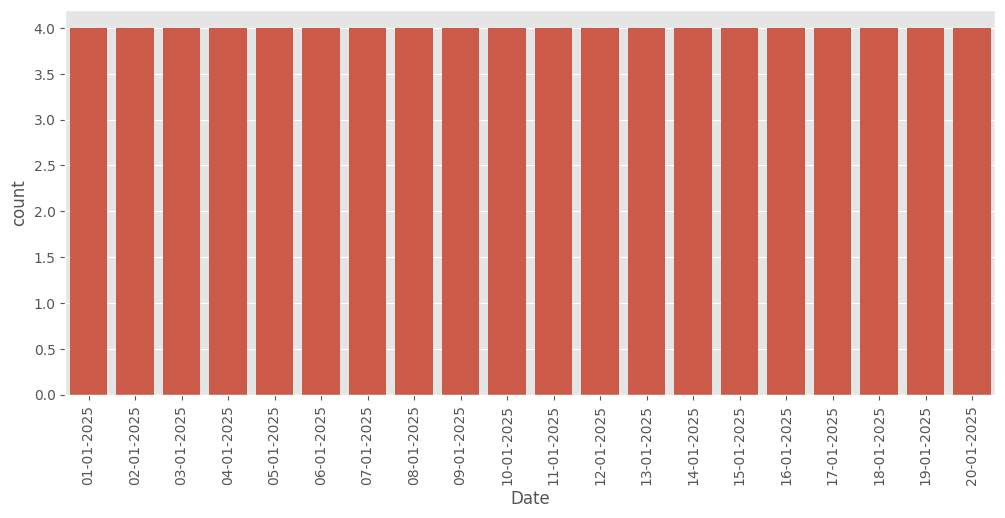

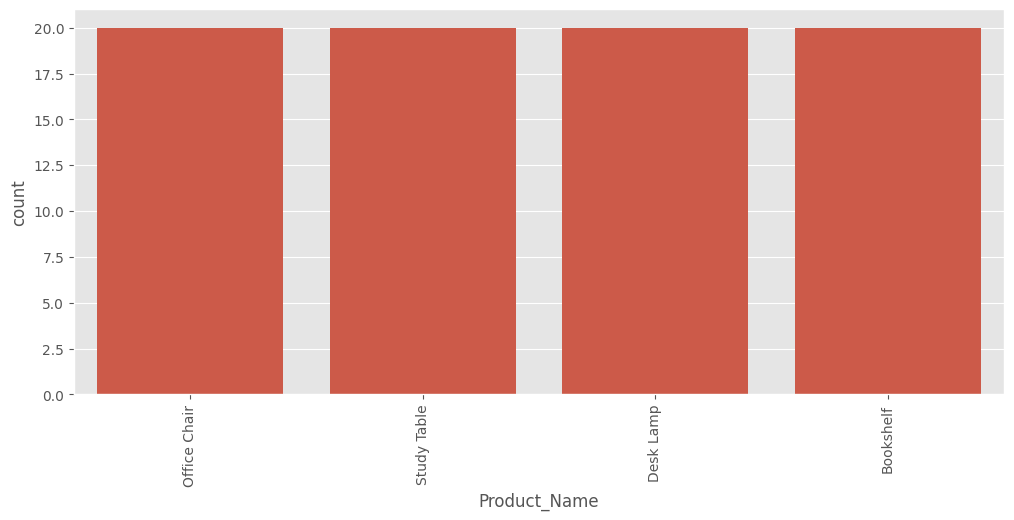

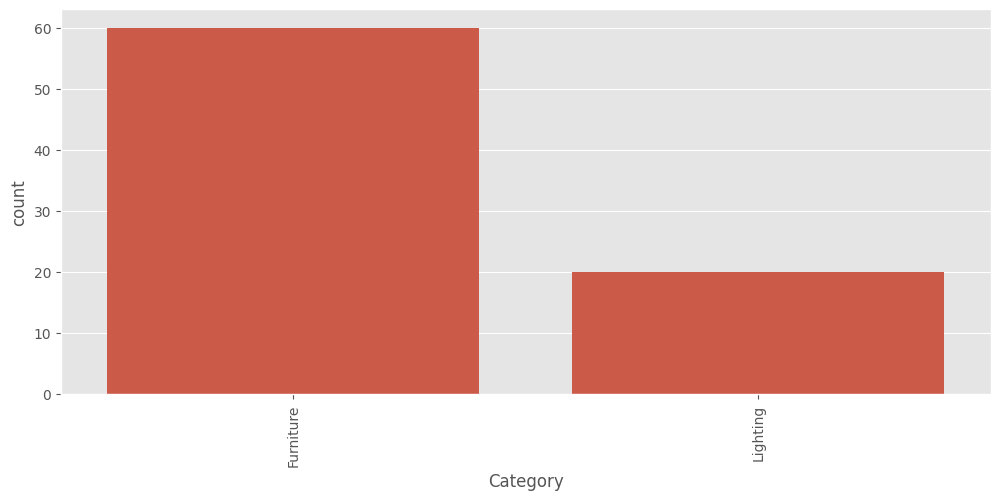

In [64]:
#Countplot
for col in cat_cols:
    plt.figure(figsize=(12,5))
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)
    plt.show()

### 12. Correlation Analysis

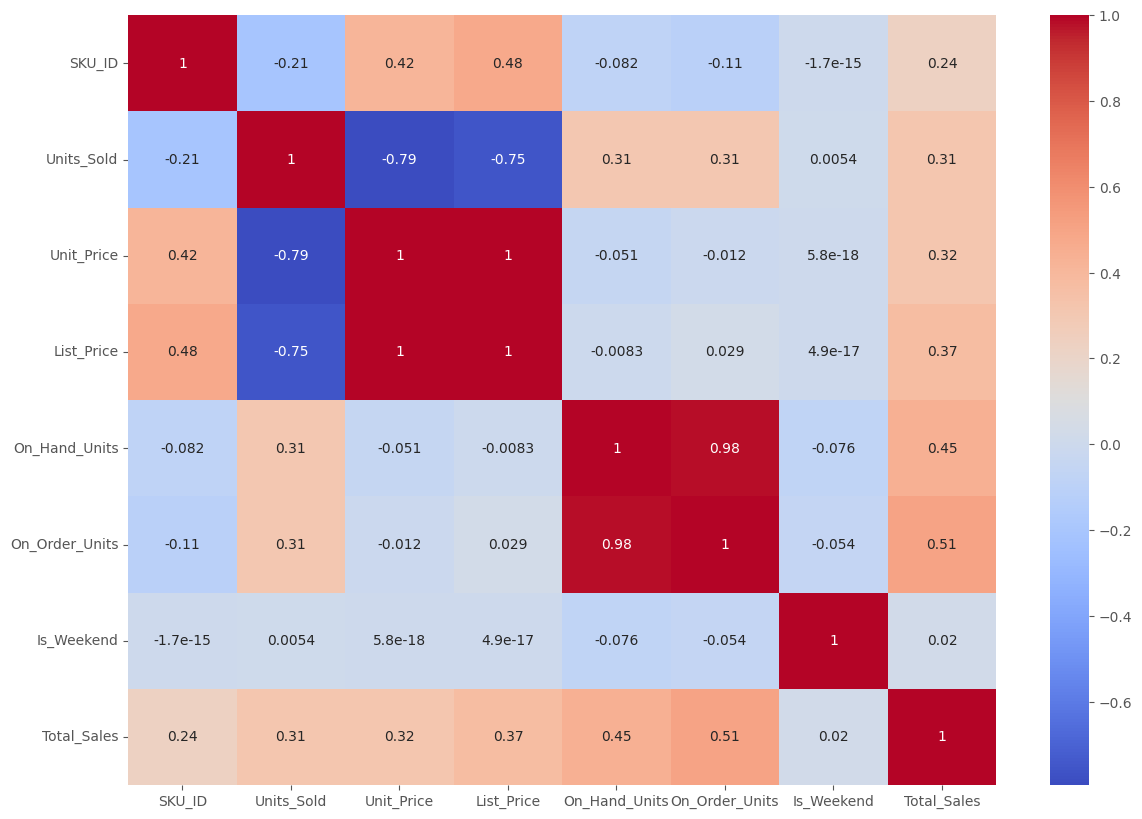

In [65]:
corr = df[num_cols].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### 13. Feature Engineering

In [66]:
df.columns.tolist()

['Date',
 'SKU_ID',
 'Product_Name',
 'Category',
 'Units_Sold',
 'Unit_Price',
 'List_Price',
 'On_Hand_Units',
 'On_Order_Units',
 'Is_Weekend',
 'Total_Sales']

In [67]:
# Total Revenue generated per record
df["Total_Sales"] = df["Units_Sold"] * df["Unit_Price"]

### 14. Data Cleaning

In [68]:
df.fillna(method="ffill", inplace=True)
df.drop_duplicates(inplace=True)

### 15. Final Dataset

In [69]:
print(df.shape)
df.head()

(80, 11)


,Date,SKU_ID,Product_Name,Category,Units_Sold,Unit_Price,List_Price,On_Hand_Units,On_Order_Units,Is_Weekend,Total_Sales
0,01-01-2025,101,Office Chair,Furniture,25,550,600,120,50,0,13750
1,01-01-2025,102,Study Table,Furniture,18,700,750,80,20,0,12600
2,01-01-2025,103,Desk Lamp,Lighting,32,450,500,95,30,0,14400
3,01-01-2025,104,Bookshelf,Furniture,20,800,900,110,40,0,16000
4,02-01-2025,101,Office Chair,Furniture,30,550,600,118,50,0,16500


In [47]:
#Save Clean Dataset
OUTPUT_PATH = r"E:\Zidio Development\Project_FORESIGHT\data\processed/processed_data.csv"
df.to_csv(OUTPUT_PATH, index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully
